# 小売売上の季節性・店舗／カテゴリ差・急変と予測限界

run_id: `v020-exp-35`。対象はKaggleからAPI取得した公開**合成データ**。主指標は販売数量、実売上金額ではない。全分析・APIコードの実行はJupyter MCPのみ。認証トークンを保存しない。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, logging
from datetime import datetime, timezone
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import nbformat
from ai_data_scientist import project_manager as pm, lifecycle, language_router
RUN_ID = 'v020-exp-35'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-35-retail-sales')
lifecycle.register_run(RUN_ID, handle.notebook_path)
initial_write_started_at = datetime.now(timezone.utc).isoformat()
lifecycle.mark_write_start(RUN_ID)
try:
    pm.ensure_notebook(handle)
    data_dir = pm.ensure_data_dir(handle)
finally:
    lifecycle.mark_write_end(RUN_ID)
    initial_write_ended_at = datetime.now(timezone.utc).isoformat()
assert language_router.detect_language('小売売上を分析してください') == 'ja'
phase_log = [{'phase': 'write', 'action': 'start', 'utc': initial_write_started_at}, {'phase': 'write', 'action': 'end', 'utc': initial_write_ended_at}]
def phase(name, action):
    phase_log.append({'phase': name, 'action': action, 'utc': datetime.now(timezone.utc).isoformat()})
def checked_start():
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行中止が要求されました')
    lifecycle.mark_execution_start(RUN_ID)
    phase('execution', 'start')
def checked_end():
    lifecycle.mark_execution_end(RUN_ID)
    phase('execution', 'end')
    if sys.exc_info()[0] is not None:
        lifecycle.mark_failed(RUN_ID)
        phase('execution', 'failed:' + sys.exc_info()[0].__name__)
checked_start()
api_status = {'authenticated': False, 'search_ok': False, 'errors': []}
search_results = []
old_logging_disable = logging.root.manager.disable
try:
    # 認証やHTTP例外の生メッセージを永続化しない。
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        logging.disable(logging.CRITICAL)
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
    api_status['authenticated'] = True
    for query in ['retail sales time series', 'retail store inventory forecasting']:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            results = api.dataset_list(search=query)
        for item in results:
            search_results.append({'query': query, 'ref': str(item.ref), 'title': str(item.title), 'bytes': getattr(item, 'total_bytes', None)})
    api_status['search_ok'] = True
except Exception as exc:
    api_status['errors'].append({'phase': 'authenticate_or_search', 'exception_type': type(exc).__name__, 'detail': '秘密情報保護のため例外メッセージと認証出力は保存しない'})
finally:
    logging.disable(old_logging_disable)
    checked_end()
print(json.dumps(api_status, ensure_ascii=False))
(data_dir / 'kaggle_search_results.json').write_text(json.dumps(search_results, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps([r for q in ['retail sales time series', 'retail store inventory forecasting'] for r in [x for x in search_results if x['query'] == q][:12]], ensure_ascii=False, indent=2))


{"authenticated": true, "search_ok": true, "errors": []}
[
  {
    "query": "retail sales time series",
    "ref": "census/retail-and-retailers-sales-time-series-collection",
    "title": "Retail and Retailers Sales Time Series Collection",
    "bytes": 58069
  },
  {
    "query": "retail sales time series",
    "ref": "census/advance-retail-sales-time-series-collection",
    "title": "Advance Retail Sales Time Series Collection",
    "bytes": 76990
  },
  {
    "query": "retail sales time series",
    "ref": "rohitsahoo/sales-forecasting",
    "title": "Superstore Sales Dataset",
    "bytes": 491942
  },
  {
    "query": "retail sales time series",
    "ref": "ssssws/chocolate-sales-dataset-2023-2024",
    "title": "Chocolate Sales Dataset 2023 - 2024",
    "bytes": 24420255
  },
  {
    "query": "retail sales time series",
    "ref": "anirudhchauhan/retail-store-inventory-forecasting-dataset",
    "title": "Retail Store Inventory Forecasting Dataset",
    "bytes": 1588139
  },
  {
  

In [2]:
# 取得: 実検索結果から店舗・商品カテゴリ・日付を含む候補を選ぶ。
checked_start()
selected_slug = 'anirudhchauhan/retail-store-inventory-forecasting-dataset'
acquisition = {'slug': selected_slug, 'status': 'pending', 'errors': []}
file_records = []
source_metadata = {}
try:
    assert api_status['search_ok'] and selected_slug in {r['ref'] for r in search_results}
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        listed = api.dataset_list_files(selected_slug)
    for f in listed.files:
        file_records.append({'name': f.name, 'bytes': getattr(f, 'total_bytes', None)})
    print('ファイル一覧:', json.dumps(file_records, ensure_ascii=False))
    csv_names = [r['name'] for r in file_records if r['name'].lower().endswith('.csv')]
    if len(csv_names) != 1:
        raise ValueError('CSVの一意選択ができません')
    filename = csv_names[0]
    raw_path = data_dir / filename
    if not raw_path.exists():
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(selected_slug, filename, path=str(data_dir), quiet=True)
    if not raw_path.exists():
        import zipfile
        zip_path = data_dir / (filename + '.zip')
        with zipfile.ZipFile(zip_path) as archive:
            candidates = [x for x in archive.namelist() if Path(x).name == Path(filename).name]
            if len(candidates) != 1:
                raise ValueError('ZIPに対応するCSVが一意ではありません')
            raw_path.write_bytes(archive.read(candidates[0]))
    provenance_path = data_dir / 'provenance.json'
    sha256 = hashlib.sha256(raw_path.read_bytes()).hexdigest()
    if provenance_path.exists():
        provenance = json.loads(provenance_path.read_text())
        assert provenance['sha256'] == sha256 and provenance['slug'] == selected_slug
    else:
        provenance = {'slug': selected_slug, 'filename': filename, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': sha256, 'method': 'Kaggle Python SDK dataset_download_file', 'url': 'https://www.kaggle.com/datasets/' + selected_slug}
        provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_metadata(selected_slug, path=str(data_dir))
    metadata_path = data_dir / 'dataset-metadata.json'
    if metadata_path.exists():
        source_metadata = json.loads(metadata_path.read_text())
    acquisition['status'] = 'downloaded'
except Exception as exc:
    acquisition['status'] = 'failed'
    acquisition['errors'].append({'exception_type': type(exc).__name__, 'detail': '秘密情報保護のため例外の生メッセージは非保存'})
    paper_path = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
    if paper_path.exists():
        paper_text = paper_path.read_text(encoding='utf-8')
        matching_lines = [line for line in paper_text.splitlines() if selected_slug in line or 'retail' in line.lower()]
        print('指定稿の対応記載:', '\n'.join(matching_lines))
    else:
        print('指定されたwhite-paper.mdが存在しません。推測による代替データは使用しません。')
finally:
    checked_end()
print('取得状態:', json.dumps(acquisition, ensure_ascii=False))
if acquisition['status'] == 'downloaded':
    print('取得記録:', json.dumps(provenance, ensure_ascii=False, indent=2))
    print('データ説明:', str(source_metadata.get('info', source_metadata).get('description', '記載なし'))[:12000])
else:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('取得失敗: 対応する公開CSVの確認が必要')

ファイル一覧: [{"name": "retail_store_inventory.csv", "bytes": 6191463}]
取得状態: {"slug": "anirudhchauhan/retail-store-inventory-forecasting-dataset", "status": "downloaded", "errors": []}
取得記録: {
  "slug": "anirudhchauhan/retail-store-inventory-forecasting-dataset",
  "filename": "retail_store_inventory.csv",
  "retrieved_at_utc": "2026-10-01T21:48:03.215973+00:00",
  "sha256": "c7b6019887d85e6bb311a76da72560463e6bf269bfadbe4b326fbff3b1000468",
  "method": "Kaggle Python SDK dataset_download_file",
  "url": "https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset"
}
データ説明: This dataset provides synthetic yet realistic data for analyzing and forecasting retail store inventory demand. It contains over 73000 rows of daily data across multiple stores and products, including attributes like sales, inventory levels, pricing, weather, promotions, and holidays.

The dataset is ideal for practicing machine learning tasks such as demand forecasting, dynamic pricing, an

In [3]:
# 基礎検査: 原本は保持し、欠損日を売上ゼロに置換しない。
import pandas as pd
import numpy as np
from IPython.display import display
from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions, data_quality, sensitivity, visualization, notebook_audit
checked_start()
try:
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(raw_path)), row_limit=1000000)
    assert not loaded.truncated
    raw = loaded.dataframe
    print('読込:', raw.shape)
    print('metadata keys:', list(source_metadata.keys()))
    display(raw.head())
    print('欠損:', raw.isna().sum().to_dict())
    print('型:', raw.dtypes.astype(str).to_dict())
    df = raw.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='raise')
    key = ['Date', 'Store ID', 'Product ID']
    print('完全重複行:', int(df.duplicated().sum()), '複合キー重複:', int(df.duplicated(key).sum()))
    print('範囲:', df['Date'].min(), df['Date'].max())
    for col in ['Store ID', 'Product ID', 'Category', 'Region', 'Seasonality']:
        print(col, df[col].value_counts().to_dict())
    print('商品ごとのカテゴリ数:', df.groupby('Product ID')['Category'].nunique().value_counts().to_dict())
    print('店舗ごとの地域数:', df.groupby('Store ID')['Region'].nunique().value_counts().to_dict())
    display(df.select_dtypes('number').describe().T)
    exploratory = eda.explore(df)
    print('EDA出力キー:', list(exploratory.keys()) if isinstance(exploratory, dict) else type(exploratory).__name__)
finally:
    checked_end()

読込: (73100, 15)
metadata keys: ['info']
欠損: {'Date': 0, 'Store ID': 0, 'Product ID': 0, 'Category': 0, 'Region': 0, 'Inventory Level': 0, 'Units Sold': 0, 'Units Ordered': 0, 'Demand Forecast': 0, 'Price': 0, 'Discount': 0, 'Weather Condition': 0, 'Holiday/Promotion': 0, 'Competitor Pricing': 0, 'Seasonality': 0}
型: {'Date': 'str', 'Store ID': 'str', 'Product ID': 'str', 'Category': 'str', 'Region': 'str', 'Inventory Level': 'int64', 'Units Sold': 'int64', 'Units Ordered': 'int64', 'Demand Forecast': 'float64', 'Price': 'float64', 'Discount': 'int64', 'Weather Condition': 'str', 'Holiday/Promotion': 'int64', 'Competitor Pricing': 'float64', 'Seasonality': 'str'}
完全重複行: 0 複合キー重複: 0
範囲: 2022-01-01 00:00:00 2024-01-01 00:00:00
Store ID {'S001': 14620, 'S002': 14620, 'S003': 14620, 'S004': 14620, 'S005': 14620}
Product ID {'P0001': 3655, 'P0002': 3655, 'P0003': 3655, 'P0004': 3655, 'P0005': 3655, 'P0006': 3655, 'P0007': 3655, 'P0008': 3655, 'P0009': 3655, 'P0010': 3655, 'P0011': 3655, 'P00

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


,count,mean,std,min,25%,50%,75%,max
Inventory Level,73100.0,274.469877,129.949514,50.00,162.00,273.000,387.0000,500.00
Units Sold,73100.0,136.464870,108.919406,0.00,49.00,107.000,203.0000,499.00
Units Ordered,73100.0,110.004473,52.277448,20.00,65.00,110.000,155.0000,200.00
Demand Forecast,73100.0,141.494720,109.254076,-9.99,53.67,113.015,208.0525,518.55
Price,73100.0,55.135108,26.021945,10.00,32.65,55.050,77.8600,100.00
Discount,73100.0,10.009508,7.083746,0.00,5.00,10.000,15.0000,20.00
Holiday/Promotion,73100.0,0.497305,0.499996,0.00,0.00,0.000,1.0000,1.00
Competitor Pricing,73100.0,55.146077,26.191408,5.03,32.68,55.010,77.8200,104.94


In [4]:
# データ定義・前提・意味的品質検査と欠損期間。
checked_start()
try:
    metadata_info = source_metadata.get('info', source_metadata)
    print('出典説明:', metadata_info.get('description', '記載なし'))
    print('出典生成方法:', metadata_info.get('userSpecifiedSources', '不明'))
    cleanup = cleaning.clean_dataset(df, operation='drop_duplicates')
    assert cleanup.rows_removed == 0
    df = cleanup.dataframe.copy()
    print('クリーニング:', {'rows_before': cleanup.rows_before, 'rows_after': cleanup.rows_after, 'rows_removed': cleanup.rows_removed, 'columns_affected': cleanup.columns_affected})
    FV = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={'identity': FV(provenance, 'verified', 'SDK取得とローカルSHA-256'), 'generation': FV('synthetic', 'verified', metadata_info.get('userSpecifiedSources')), 'license': FV(metadata_info.get('licenses'), 'verified', 'Kaggle metadata')},
        dataset_scope={'period': FV([str(df.Date.min().date()), str(df.Date.max().date())], 'verified', 'CSV実測'), 'grain': FV('日付×店舗ID×商品ID', 'verified', '複合キー検査'), 'population': FV('現実の小売母集団への対応なし', 'verified', '合成データの出典説明')},
        variables={
            'Units Sold': {'definition': FV('当日の販売数量', 'verified', '出典のUnits Sold説明'), 'unit': FV('個数。ただし異なる商品間の数量は金銭価値ではない', 'verified', '出典のUnits Sold説明')},
            'Category': {'definition': FV('行に付与された商品カテゴリ', 'verified', '出典'), 'fixed_product_membership': FV(False, 'verified', '全20商品IDに5カテゴリが出現')},
            'Region': {'definition': FV('店舗の地域ラベル', 'verified', '出典'), 'stable_store_attribute': FV(False, 'verified', '全5店舗IDに4地域が出現')},
            'Price': {'currency': FV(None, 'unknown'), 'definition': FV('行の単価候補', 'inferred', '列名と値域'), 'discount_included': FV(None, 'unknown')},
            'Discount': {'unit': FV('百分率候補', 'inferred', '0,5,10,15,20'), 'tax_and_returns': FV(None, 'unknown')},
            'Seasonality': {'calendar_definition': FV(None, 'unknown')},
            'Demand Forecast': {'availability_at_forecast_origin': FV(None, 'unknown'), 'generation': FV('past trendsとの記述だが作成・検証方法不明', 'verified', '出典')}
        }, transformations=('日付をdatetime化', '欠損日を補完しない', '売上主指標はUnits Sold', '金額候補はPrice×Units Soldの未確認代理値'))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str))
    print('未解決unknown:', [(p, asdict(v)) for p, v in definition_manifest.unresolved_fields()])
    print('inferred注意:', 'Priceの意味、Discountの百分率解釈は推定。純売上・通貨を確認した事実ではない。')
    schema = {c: {'not_null': True} for c in df.columns}
    for c in ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Competitor Pricing']:
        schema[c]['min'] = 0
    schema['Discount'].update({'min': 0, 'max': 100})
    schema['Holiday/Promotion']['allowed'] = [0, 1]
    semantic_records = data_quality.detect_anomalies(df, schema=schema)
    print('意味的異常:', [{'column': r.column, 'rule': r.rule, 'row_count': r.row_count, 'sample_indices': list(r.row_indices[:5])} for r in semantic_records])
    assert set(key).issubset(df.columns)
    calendar = pd.date_range(df.Date.min(), df.Date.max(), freq='D')
    pairs = df[['Store ID', 'Product ID']].drop_duplicates()
    expected = pd.MultiIndex.from_product([calendar, sorted(df['Store ID'].unique()), sorted(df['Product ID'].unique())], names=key)
    actual = pd.MultiIndex.from_frame(df[key])
    missing_keys = expected.difference(actual)
    missing_dates = calendar.difference(pd.DatetimeIndex(df.Date.unique()))
    coverage = df.groupby('Date').size().reindex(calendar)
    print('粒度・期間:', {'days': len(calendar), 'stores': df['Store ID'].nunique(), 'products': df['Product ID'].nunique(), 'expected_rows': len(expected), 'observed_rows': len(df), 'missing_keys': len(missing_keys), 'missing_dates': len(missing_dates), 'rows_per_day_min': int(coverage.min()), 'rows_per_day_max': int(coverage.max()), 'zero_sales_rows': int(df['Units Sold'].eq(0).sum())})
    print('欠損日一覧:', [str(x.date()) for x in missing_dates])
    missing_keys.to_frame(index=False).to_csv(data_dir / 'missing_date_store_product_keys.csv', index=False)
    daily = df.groupby('Date')['Units Sold'].sum(min_count=1).reindex(calendar).rename('販売数量')
    daily.index.name = '日付'
    monthly = daily.resample('MS').agg(['sum', 'mean', 'count'])
    monthly['expected_days'] = monthly.index.days_in_month
    monthly['complete'] = monthly['count'].eq(monthly['expected_days'])
    display(monthly)
    assumptions_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target': '合成データの販売数量。店舗差はStore ID、カテゴリ差は行ラベルで記述', 'aggregation': '日計、7日移動平均、完全月の日平均、完全週', 'missing': '欠損はゼロ扱いしない', 'forecast': '時間順ホールドアウト。Demand Forecastは未来可用性不明のため使わない'},
        causal_scope='descriptive',
        assumptions=(
            analysis_assumptions.Assumption('balanced-panel', '日×店舗×商品の完全パネル', 'tested', impact_if_false='合計差がカバレッジ差に変わる', conclusion_critical=True),
            analysis_assumptions.Assumption('fixed-category', '商品IDにカテゴリが固定', 'rejected', impact_if_false='固定商品群の需要差は推定できない', conclusion_critical=True),
            analysis_assumptions.Assumption('revenue-definition', 'PriceとDiscountで実売上金額を復元できる', 'assumed', impact_if_false='金額比較は実売上ではない', conclusion_critical=True),
            analysis_assumptions.Assumption('future-stability', '合成過程の将来安定性', 'assumed', impact_if_false='過去の予測成績は将来性能を保証しない', conclusion_critical=True),
            analysis_assumptions.Assumption('full-months', '不完全な2024年1月は月次比較から除外', 'tested', conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumptions_manifest)
    print('分析前提manifest:', json.dumps(asdict(assumptions_manifest), ensure_ascii=False))
    print('前提上の警告（全件）:', [asdict(f) for f in assumption_findings])
    daily.to_csv(data_dir / 'daily_units.csv')
    monthly.to_csv(data_dir / 'monthly_coverage_and_units.csv')
finally:
    checked_end()

出典説明: This dataset provides synthetic yet realistic data for analyzing and forecasting retail store inventory demand. It contains over 73000 rows of daily data across multiple stores and products, including attributes like sales, inventory levels, pricing, weather, promotions, and holidays.

The dataset is ideal for practicing machine learning tasks such as demand forecasting, dynamic pricing, and inventory optimization. It allows data scientists to explore time series forecasting techniques, study the impact of external factors like weather and holidays on sales, and build advanced models to optimize supply chain performance.

# Challenges for Data Scientists:
**Challenge 1: Time Series Demand Forecasting**
Predict daily product demand across stores using historical sales and inventory data. Can you build an LSTM-based forecasting model that outperforms classical methods like ARIMA?

**Challenge 2: Inventory Optimization**
Optimize inventory levels by analyzing sales trends and minimi

,sum,mean,count,expected_days,complete
日付,,,,,
2022-01-01,419938,13546.387097,31,31,True
2022-02-01,391052,13966.142857,28,28,True
2022-03-01,426073,13744.290323,31,31,True
2022-04-01,407380,13579.333333,30,30,True
2022-05-01,414799,13380.612903,31,31,True
2022-06-01,415509,13850.300000,30,30,True
2022-07-01,426628,13762.193548,31,31,True
2022-08-01,424916,13706.967742,31,31,True
2022-09-01,411610,13720.333333,30,30,True


In [5]:
# 初回分析: 月の長さと部分月を分け、行数補正も併記。
checked_start()
try:
    complete_daily = daily.loc['2022-01-01':'2023-12-31']
    calendar_frame = complete_daily.to_frame()
    calendar_frame['year'] = calendar_frame.index.year
    calendar_frame['month'] = calendar_frame.index.month
    calendar_frame['weekday'] = calendar_frame.index.dayofweek
    month_year = calendar_frame.pivot_table(index='month', columns='year', values='販売数量', aggfunc='mean')
    weekday_year = calendar_frame.pivot_table(index='weekday', columns='year', values='販売数量', aggfunc='mean')
    month_spread = (month_year.max() - month_year.min()) / month_year.mean() * 100
    acf_table = pd.DataFrame({'lag_days': [1, 7, 14, 28, 365], 'autocorrelation': [complete_daily.autocorr(lag) for lag in [1, 7, 14, 28, 365]]})
    store_daily = df.groupby(['Date', 'Store ID'])['Units Sold'].sum().unstack().loc[complete_daily.index]
    category_daily = df.groupby(['Date', 'Category'])['Units Sold'].agg(['sum', 'count', 'mean'])
    category_summary = df.groupby('Category')['Units Sold'].agg(['sum', 'count', 'mean'])
    category_summary['share_pct'] = category_summary['sum'] / category_summary['sum'].sum() * 100
    store_summary = store_daily.agg(['mean', 'std']).T
    store_summary['per_product_daily_mean'] = store_summary['mean'] / 20
    units_stats = {'days': len(calendar), 'missing_keys': len(missing_keys), 'daily_mean': float(complete_daily.mean()), 'daily_cv_pct': float(complete_daily.std() / complete_daily.mean() * 100), 'equal_month_weight_2023_vs_2022_pct': float((month_year[2023].mean() / month_year[2022].mean() - 1) * 100), 'month_profile_year_correlation': float(month_year[2022].corr(month_year[2023])), 'month_spread_2022_pct': float(month_spread[2022]), 'month_spread_2023_pct': float(month_spread[2023]), 'store_mean_max_min_pct': float((store_summary['mean'].max() / store_summary['mean'].min() - 1) * 100), 'category_total_max_min_pct': float((category_summary['sum'].max() / category_summary['sum'].min() - 1) * 100), 'category_per_row_max_min_pct': float((category_summary['mean'].max() / category_summary['mean'].min() - 1) * 100)}
    print('初回結果:', json.dumps(units_stats, ensure_ascii=False))
    print('自己相関:'); display(acf_table)
    print('月別日平均数量:'); display(month_year)
    print('曜日別日平均数量（月曜=0）:'); display(weekday_year)
    print('店舗比較:'); display(store_summary)
    print('カテゴリ比較（行ラベル）:'); display(category_summary)
    # 過去28日の中央値/MADだけで日次急変をスクリーニング。
    hist_median = complete_daily.shift(1).rolling(28, min_periods=28).median()
    hist_mad = complete_daily.shift(1).rolling(28, min_periods=28).apply(lambda a: np.median(np.abs(a - np.median(a))), raw=True)
    robust_z = (complete_daily - hist_median) / (1.4826 * hist_mad).replace(0, np.nan)
    initial_flags = pd.DataFrame({'units': complete_daily, 'prior28_median': hist_median, 'robust_z': robust_z, 'pct_vs_previous_day': complete_daily.pct_change() * 100}).loc[robust_z.abs().gt(3.5)]
    print('初回急変候補数:', len(initial_flags)); display(initial_flags)
    print('初回解釈: 年ごとの月形状、ACF、行数補正、急変候補を点検する。月別の最大最小だけで季節性や構造変化とは断定しない。')
    for name, table in [('monthly_year_daily_mean', month_year), ('weekday_year_daily_mean', weekday_year), ('store_summary', store_summary), ('category_summary', category_summary), ('initial_change_flags', initial_flags)]:
        table.to_csv(data_dir / (name + '.csv'))
finally:
    checked_end()

初回結果: {"days": 731, "missing_keys": 0, "daily_mean": 13647.038356164383, "daily_cv_pct": 7.5661747321858615, "equal_month_weight_2023_vs_2022_pct": -0.43696121192455806, "month_profile_year_correlation": 0.395367853021756, "month_spread_2022_pct": 4.864962527925344, "month_spread_2023_pct": 5.559790658011624, "store_mean_max_min_pct": 2.338872808937764, "category_total_max_min_pct": 3.294426942633044, "category_per_row_max_min_pct": 2.0435657959027465}
自己相関:
月別日平均数量:
曜日別日平均数量（月曜=0）:
店舗比較:
カテゴリ比較（行ラベル）:
初回急変候補数: 4
初回解釈: 年ごとの月形状、ACF、行数補正、急変候補を点検する。月別の最大最小だけで季節性や構造変化とは断定しない。


,lag_days,autocorrelation
0,1,0.021739
1,7,-0.010411
2,14,0.016468
3,28,-0.019305
4,365,0.070069


year,2022,2023
month,,
1,13546.387097,13658.322581
2,13966.142857,13756.000000
3,13744.290323,13436.193548
4,13579.333333,13369.233333
5,13380.612903,13505.580645
6,13850.300000,13521.366667
7,13762.193548,14126.419355
8,13706.967742,13435.516129
9,13720.333333,13512.033333


year,2022,2023
weekday,,
0,13509.807692,13514.230769
1,13705.192308,13756.346154
2,13623.826923,13699.192308
3,13819.403846,13636.980769
4,13801.865385,13568.423077
5,13504.000000,13559.423077
6,13768.980769,13594.622642


,mean,std,per_product_daily_mean
Store ID,,,
S001,2703.386301,480.426161,135.169315
S002,2719.795890,467.094373,135.989795
S003,2766.615068,485.860879,138.330753
S004,2707.810959,462.567985,135.390548
S005,2749.430137,494.847214,137.471507


,sum,count,mean,share_pct
Category,,,,
Clothing,1999166,14626,136.685765,20.040595
Electronics,1960432,14521,135.006680,19.652307
Furniture,2025017,14699,137.765630,20.299738
Groceries,2000482,14611,136.916159,20.053787
Toys,1990485,14643,135.934235,19.953573


,units,prior28_median,robust_z,pct_vs_previous_day
日付,,,,
2022-03-15,11057,13931.5,-4.871416,-18.223504
2022-06-21,17239,13491.0,4.522346,31.695951
2022-08-09,11533,14159.5,-3.761253,-19.557788
2022-08-20,11792,14025.0,-4.416827,-15.999430


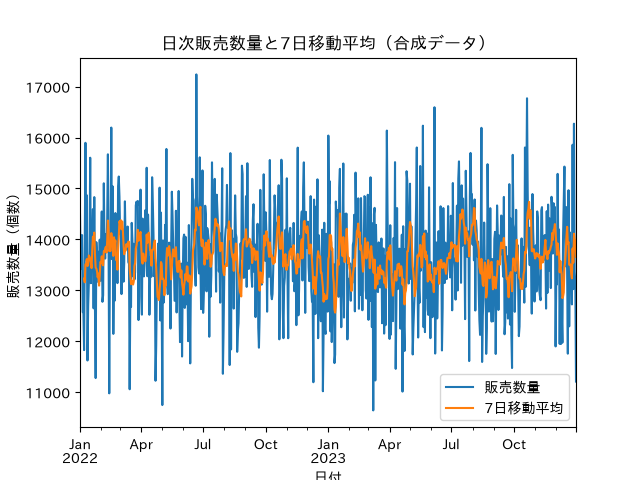

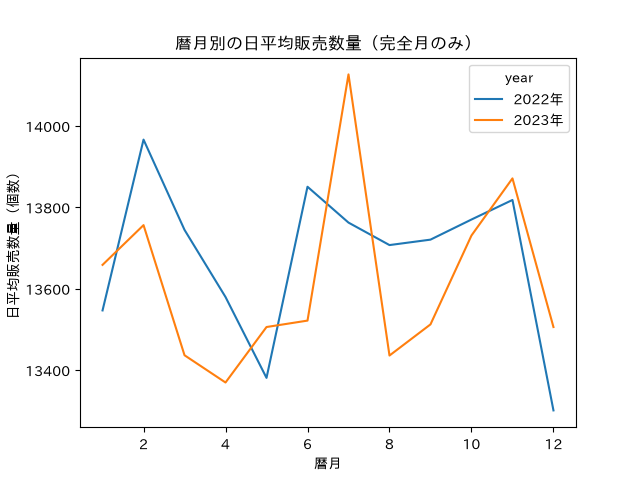

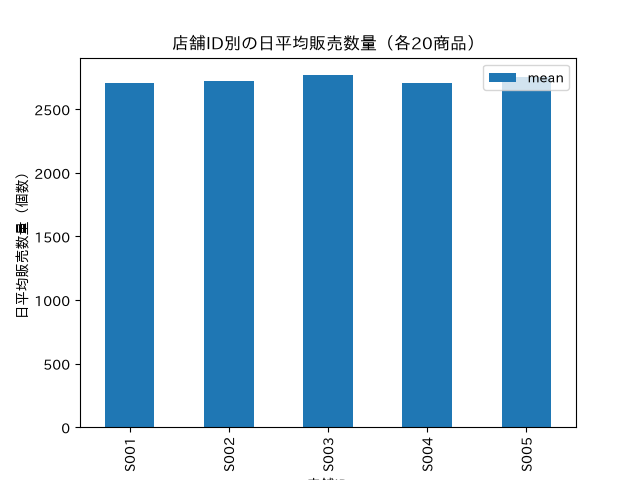

In [6]:
# CHART: initial-overview
import warnings
chart_registry = {}
chart_warning_log = []
def show_chart(frame, kind, x, y, title, xlabel, ylabel, filename):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        png = visualization.render_chart(frame, kind=kind, x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
    glyph_warnings = [str(w.message) for w in caught if 'Glyph' in str(w.message)]
    if glyph_warnings:
        raise RuntimeError('図の欠落グリフ: ' + '; '.join(glyph_warnings))
    chart_warning_log.extend([str(w.message) for w in caught])
    chart_registry[filename] = {'title': title, 'xlabel': xlabel, 'ylabel': ylabel, 'legend': [str(c) for c in (y if isinstance(y, list) else [y])], 'missing_glyphs': [], 'glyph_check': 'matplotlib描画中にGlyph警告がないことを検査', 'sha256': hashlib.sha256(png).hexdigest()}
    (data_dir / filename).write_bytes(png)
    bundle = visualization.build_image_output(png)
    display(bundle['data'], raw=True)
checked_start()
try:
    trend = complete_daily.to_frame().assign(**{'7日移動平均': complete_daily.rolling(7, min_periods=7).mean()}).reset_index()
    show_chart(trend, 'line', '日付', ['販売数量', '7日移動平均'], '日次販売数量と7日移動平均（合成データ）', '日付', '販売数量（個数）', 'daily-trend.png')
    monthly_chart = month_year.rename(columns={2022: '2022年', 2023: '2023年'}).reset_index().rename(columns={'month': '月'})
    show_chart(monthly_chart, 'line', '月', ['2022年', '2023年'], '暦月別の日平均販売数量（完全月のみ）', '暦月', '日平均販売数量（個数）', 'monthly-seasonality.png')
    show_chart(store_summary.reset_index(), 'bar', 'Store ID', 'mean', '店舗ID別の日平均販売数量（各20商品）', '店舗ID', '日平均販売数量（個数）', 'store-comparison.png')
finally:
    checked_end()

In [7]:
# 反復1: ラベルの変動と構成効果、暦月の再現性を解消。
from ai_data_scientist import stats_analysis
iteration_history = []
request1 = 'カテゴリ総売上の差が販売行数の差によるものか、1行当たり販売数量の差によるものかを分解してください。同一商品のカテゴリ変更と同一店舗の地域変更を定量化し、Seasonalityラベルが暦の季節を意味するか確認してください。月別の形状が翌年にも再現するかと、店舗・カテゴリ差の不確実性を日単位のブロック再標本化で調べてください。'
print('追加依頼文（原文）:', request1)
print('選定理由: カテゴリ差と季節性の解釈を左右するラベル不整合・構成効果が初回結果で未解決。')
checked_start()
try:
    ordered = df.sort_values(key)
    by_pair = ordered.groupby(['Store ID', 'Product ID'])
    prev_category = by_pair['Category'].shift(1)
    prev_region = by_pair['Region'].shift(1)
    eligible = prev_category.notna()
    label_checks = {'category_switch_rate': float(ordered.loc[eligible, 'Category'].ne(prev_category[eligible]).mean()), 'region_switch_rate': float(ordered.loc[eligible, 'Region'].ne(prev_region[eligible]).mean()), 'all_product_ids_multicategory': int(df.groupby('Product ID')['Category'].nunique().gt(1).sum()), 'all_store_ids_multiregion': int(df.groupby('Store ID')['Region'].nunique().gt(1).sum()), 'days_with_all_four_seasonality_labels': int(df.groupby('Date')['Seasonality'].nunique().eq(4).sum()), 'days_observed': int(df.Date.nunique())}
    print('ラベル検査:', json.dumps(label_checks, ensure_ascii=False))
    count_ratio = category_summary['count'].max() / category_summary['count'].min()
    cat_pair = ['Furniture', 'Electronics']
    decomposition = {'comparison': 'Furniture/Electronics', 'total_ratio': float(category_summary.loc[cat_pair[0], 'sum'] / category_summary.loc[cat_pair[1], 'sum']), 'row_count_ratio': float(category_summary.loc[cat_pair[0], 'count'] / category_summary.loc[cat_pair[1], 'count']), 'per_row_units_ratio': float(category_summary.loc[cat_pair[0], 'mean'] / category_summary.loc[cat_pair[1], 'mean'])}
    assert np.isclose(decomposition['total_ratio'], decomposition['row_count_ratio'] * decomposition['per_row_units_ratio'])
    print('カテゴリ差の乗法分解:', json.dumps(decomposition, ensure_ascii=False))
    month_correlation = stats_analysis.correlation(month_year.rename(columns={2022: 'y2022', 2023: 'y2023'}), 'y2022', 'y2023', language='ja')
    print('月形状相関:', asdict(month_correlation))
    category_means_daily = category_daily['mean'].unstack().loc[complete_daily.index]
    # 固定した基準に対する同日差。カテゴリは固定商品群でなく行ラベル。
    contrasts = pd.concat([store_daily.drop(columns='S001').sub(store_daily['S001'], axis=0).add_prefix('store_vs_S001:'), category_means_daily.drop(columns='Electronics').sub(category_means_daily['Electronics'], axis=0).add_prefix('category_vs_Electronics:')], axis=1)
    rng = np.random.default_rng(35)
    n_days, block, n_boot = len(contrasts), 7, 2000
    starts = rng.integers(0, n_days, size=(n_boot, int(np.ceil(n_days / block))))
    boot_indices = ((starts[:, :, None] + np.arange(block)) % n_days).reshape(n_boot, -1)[:, :n_days]
    point = contrasts.mean().to_numpy()
    boot_means = contrasts.to_numpy()[boot_indices].mean(axis=1)
    scales = boot_means.std(axis=0, ddof=1)
    max_stats = np.max(np.abs((boot_means - point) / scales), axis=1)
    critical = np.quantile(max_stats, 0.95)
    comparison_ci = pd.DataFrame({'comparison': contrasts.columns, 'mean_difference': point, 'simultaneous95_low': point - critical * scales, 'simultaneous95_high': point + critical * scales})
    comparison_ci['unit'] = ['店舗日計個数'] * 4 + ['行当たり個数'] * 4
    display(comparison_ci)
    # 月の最大最小差を、同じ月日数のシャッフル帰無分布と比較（探索的、IID前提）。
    permutation_records = []
    for year in [2022, 2023]:
        y = complete_daily.loc[str(year)]
        observed = float(y.groupby(y.index.month).mean().max() - y.groupby(y.index.month).mean().min())
        simulated = np.array([pd.Series(rng.permutation(y.to_numpy()), index=y.index).groupby(y.index.month).mean().pipe(lambda m: m.max() - m.min()) for _ in range(1000)])
        permutation_records.append({'year': year, 'observed_max_min_units': observed, 'permutation_p': float((1 + (simulated >= observed).sum()) / 1001)})
    permutation_table = pd.DataFrame(permutation_records)
    display(permutation_table)
    print('残る限界: 暦季節ラベルの定義なし。同日に全4ラベルがあり、地理も不整合なのでSeasonalityを暦の代理にしない。月形状は12組・2周期のみ。シャッフル検定はIID前提で因果・季節性の不存在を証明しない。CIは7日循環ブロックと選んだ8比較に限定。')
    iteration_history.append({'iteration': 1, 'request': request1, 'reason': 'ラベル固定性とカテゴリ構成・月形状の再現性', 'result': {'labels': label_checks, 'decomposition': decomposition, 'month_correlation': asdict(month_correlation)}, 'evidence': 'このセルのラベル検査、乗法分解、同時95%区間、暦月シャッフル表', 'remaining_limits': '合成データ、カテゴリ不安定、月12組、2年、探索的検定'})
    comparison_ci.to_csv(data_dir / 'comparison_block_bootstrap_ci.csv', index=False)
    permutation_table.to_csv(data_dir / 'seasonality_permutation.csv', index=False)
finally:
    checked_end()

追加依頼文（原文）: カテゴリ総売上の差が販売行数の差によるものか、1行当たり販売数量の差によるものかを分解してください。同一商品のカテゴリ変更と同一店舗の地域変更を定量化し、Seasonalityラベルが暦の季節を意味するか確認してください。月別の形状が翌年にも再現するかと、店舗・カテゴリ差の不確実性を日単位のブロック再標本化で調べてください。
選定理由: カテゴリ差と季節性の解釈を左右するラベル不整合・構成効果が初回結果で未解決。
ラベル検査: {"category_switch_rate": 0.7996712328767124, "region_switch_rate": 0.7493561643835617, "all_product_ids_multicategory": 20, "all_store_ids_multiregion": 5, "days_with_all_four_seasonality_labels": 731, "days_observed": 731}
カテゴリ差の乗法分解: {"comparison": "Furniture/Electronics", "total_ratio": 1.0329442694263304, "row_count_ratio": 1.0122581089456648, "per_row_units_ratio": 1.0204356579590275}
月形状相関: {'statistic': 0.395367853021756, 'p_value': 0.20334286825784387, 'interpretation': '相関係数は 0.3954 (p=0.2033) で、中程度の正の相関が見られます。'}
残る限界: 暦季節ラベルの定義なし。同日に全4ラベルがあり、地理も不整合なのでSeasonalityを暦の代理にしない。月形状は12組・2周期のみ。シャッフル検定はIID前提で因果・季節性の不存在を証明しない。CIは7日循環ブロックと選んだ8比較に限定。


,comparison,mean_difference,simultaneous95_low,simultaneous95_high,unit
0,store_vs_S001:S002,16.409589,-57.074500,89.893678,店舗日計個数
1,store_vs_S001:S003,63.228767,-15.423469,141.881003,店舗日計個数
2,store_vs_S001:S004,4.424658,-66.236639,75.085954,店舗日計個数
3,store_vs_S001:S005,46.043836,-27.783188,119.870859,店舗日計個数
4,category_vs_Electronics:Clothing,1.561179,-2.109892,5.232250,行当たり個数
5,category_vs_Electronics:Furniture,2.527791,-0.823487,5.879070,行当たり個数
6,category_vs_Electronics:Groceries,2.054480,-1.628955,5.737915,行当たり個数
7,category_vs_Electronics:Toys,0.889981,-2.665740,4.445703,行当たり個数


,year,observed_max_min_units,permutation_p
0,2022,665.465438,0.297702
1,2023,757.186022,0.191808


In [8]:
# 反復2: 未来情報を使わない固定起点の予測可能性評価。
request2 = '月や曜日のパターンが実際に予測へ役立つか、2023年の複数起点から14・28・56日先を時間順に検証してください。過去平均、直近平均、曜日平均、月平均、7日季節ナイーブを同じ期間で比較し、全店合計と店舗別の誤差、予測区間の幅と被覆率を示してください。Demand Forecast列に目的変数リークを疑う根拠があるかも確認し、使用可否を説明してください。'
print('追加依頼文（原文）:', request2)
print('選定理由: 弱いACFだけでは予測性能は分からず、既存予測列の可用時点が不明。')
checked_start()
try:
    origins = pd.date_range('2023-01-01', '2023-11-01', freq='MS')
    methods = ['mean', 'last28', 'weekday', 'month', 'seasonal7']
    def prediction(train, dates, method):
        assert train.index.max() < dates.min()
        if method == 'mean':
            return np.full(len(dates), train.mean())
        if method == 'last28':
            return np.full(len(dates), train.tail(28).mean())
        if method == 'weekday':
            return train.groupby(train.index.dayofweek).mean().reindex(dates.dayofweek).to_numpy()
        if method == 'month':
            return train.groupby(train.index.month).mean().reindex(dates.month).to_numpy()
        if method == 'seasonal7':
            return np.resize(train.tail(7).to_numpy(), len(dates))
        raise ValueError('未対応の予測法')
    forecast_rows = []
    interval_rows = []
    for origin in origins:
        train = complete_daily.loc[complete_daily.index < origin]
        for horizon in [14, 28, 56]:
            dates = pd.date_range(origin, periods=horizon, freq='D')
            truth = complete_daily.reindex(dates)
            assert truth.notna().all()
            for method in methods:
                pred = prediction(train, dates, method)
                for date, actual_value, predicted_value in zip(dates, truth, pred, strict=True):
                    forecast_rows.append({'origin': origin, 'horizon': horizon, 'date': date, 'method': method, 'actual': float(actual_value), 'prediction': float(predicted_value), 'abs_error': float(abs(actual_value - predicted_value))})
            if horizon == 28:
                for level in [0.80, 0.95]:
                    alpha = 1 - level
                    low, high = train.quantile([alpha / 2, 1 - alpha / 2])
                    interval_rows.append({'origin': origin, 'level': level, 'lower': low, 'upper': high, 'width': high - low, 'coverage': truth.between(low, high).mean()})
    forecast_cases = pd.DataFrame(forecast_rows)
    forecast_metrics = forecast_cases.groupby(['horizon', 'method']).agg(MAE=('abs_error', 'mean'), total_error=('abs_error', 'sum'), total_actual=('actual', 'sum'), n=('actual', 'size'))
    forecast_metrics['WAPE_pct'] = forecast_metrics['total_error'] / forecast_metrics['total_actual'] * 100
    forecast_metrics = forecast_metrics[['MAE', 'WAPE_pct', 'n']]
    print('固定起点の予測比較（起点間に重複日あり・同一起点同一期間で比較）:'); display(forecast_metrics)
    interval_table = pd.DataFrame(interval_rows)
    interval_summary = interval_table.groupby('level')[['width', 'coverage']].mean()
    print('過去経験分布の予測区間（安定分布の仮定、推定誤差の補正なし）:'); display(interval_summary)
    panel_error = []
    for store in store_daily.columns:
        series = store_daily[store]
        for origin in origins:
            train = series.loc[series.index < origin]
            dates = pd.date_range(origin, periods=28)
            actual_store = series.reindex(dates)
            for method in ['mean', 'weekday', 'month', 'seasonal7']:
                pred_store = prediction(train, dates, method)
                panel_error.append({'store': store, 'origin': origin, 'method': method, 'absolute_error': float(np.abs(actual_store - pred_store).sum()), 'actual_sum': float(actual_store.sum()), 'n': 28})
    store_forecast = pd.DataFrame(panel_error).groupby(['store', 'method']).sum(numeric_only=True)
    store_forecast['WAPE_pct'] = 100 * store_forecast['absolute_error'] / store_forecast['actual_sum']
    print('店舗別28日予測WAPE:'); display(store_forecast[['WAPE_pct']].unstack())
    errors_by_origin = forecast_cases.loc[forecast_cases.horizon.eq(28)].groupby(['origin', 'method']).abs_error.mean().unstack()
    rng_forecast = np.random.default_rng(3502)
    origin_indices = rng_forecast.integers(0, len(origins), size=(2000, len(origins)))
    forecast_differences = []
    for method in ['weekday', 'month', 'seasonal7']:
        paired = (errors_by_origin[method] - errors_by_origin['mean']).to_numpy()
        boot = paired[origin_indices].mean(axis=1)
        forecast_differences.append({'method': method, 'MAE_difference_vs_mean': paired.mean(), 'bootstrap95_low': np.quantile(boot, 0.025), 'bootstrap95_high': np.quantile(boot, 0.975)})
    print('平均法との起点対応差（負なら改善、重複起点ゆえ参考区間）:'); display(pd.DataFrame(forecast_differences))
    forecast_plan = sensitivity.SensitivityPlan(parameter_grid={'horizon': [28, 14, 56], 'method': methods}, max_runs=15)
    forecast_sensitivity = sensitivity.run_sensitivity(forecast_plan, lambda horizon, method: float(forecast_metrics.loc[(horizon, method), 'WAPE_pct']), stability_tolerance=0.20)
    print('予測感度:', json.dumps(asdict(forecast_sensitivity), ensure_ascii=False))
    forecast_residual = df['Demand Forecast'] - df['Units Sold']
    leakage_check = {'same_row_correlation': float(df['Demand Forecast'].corr(df['Units Sold'])), 'residual_min': float(forecast_residual.min()), 'residual_max': float(forecast_residual.max()), 'residual_mean': float(forecast_residual.mean()), 'negative_forecast_rows': int(df['Demand Forecast'].lt(0).sum()), 'same_row_MAE': float(forecast_residual.abs().mean())}
    print('既存予測列の警告:', json.dumps(leakage_check, ensure_ascii=False))
    print('結論: 高相関と狭い残差は合成目的値由来の疑いだがリークの証明ではない。作成方法・起点可用性を確認できず、Demand Forecastは予測入力・有効なベンチマークに使わない。平均の合計予測が良くても異種商品100行の平均化効果で、個店・個商品の需要予測精度とは異なる。')
    iteration_history.append({'iteration': 2, 'request': request2, 'reason': '時系列外部評価と既存予測列の可用性', 'result': {'mean_28_WAPE_pct': float(forecast_metrics.loc[(28, 'mean'), 'WAPE_pct']), 'sensitivity_stable': forecast_sensitivity.stable, 'max_relative_deviation': forecast_sensitivity.max_relative_deviation, 'leakage_check': leakage_check}, 'evidence': 'このセルの起点別・店舗別予測表と区間、感度report、既存予測残差', 'remaining_limits': '合成過程、2年、11起点の重複、経験区間は分布安定性仮定、リークは未確証'})
    forecast_cases.to_csv(data_dir / 'forecast_cases.csv', index=False)
    forecast_metrics.to_csv(data_dir / 'forecast_metrics.csv')
    store_forecast.to_csv(data_dir / 'store_forecast_metrics.csv')
    interval_table.to_csv(data_dir / 'forecast_intervals.csv', index=False)
finally:
    checked_end()

追加依頼文（原文）: 月や曜日のパターンが実際に予測へ役立つか、2023年の複数起点から14・28・56日先を時間順に検証してください。過去平均、直近平均、曜日平均、月平均、7日季節ナイーブを同じ期間で比較し、全店合計と店舗別の誤差、予測区間の幅と被覆率を示してください。Demand Forecast列に目的変数リークを疑う根拠があるかも確認し、使用可否を説明してください。
選定理由: 弱いACFだけでは予測性能は分からず、既存予測列の可用時点が不明。
固定起点の予測比較（起点間に重複日あり・同一起点同一期間で比較）:
過去経験分布の予測区間（安定分布の仮定、推定誤差の補正なし）:
店舗別28日予測WAPE:
平均法との起点対応差（負なら改善、重複起点ゆえ参考区間）:
予測感度: {"results": [{"specification": {"horizon": 28, "method": "mean"}, "value": 6.181782065966815}, {"specification": {"horizon": 28, "method": "last28"}, "value": 6.305909996182195}, {"specification": {"horizon": 28, "method": "weekday"}, "value": 6.211585945300826}, {"specification": {"horizon": 28, "method": "month"}, "value": 6.221450022547417}, {"specification": {"horizon": 28, "method": "seasonal7"}, "value": 8.22026404199838}, {"specification": {"horizon": 14, "method": "mean"}, "value": 6.128890583382675}, {"specification": {"horizon": 14, "method": "last28"}, "value": 6.129300449554746}, {"specification": {"horizon": 14, "method": "weekday"}, 

MAE  WAPE_pct    n
horizon method                               
14      last28      832.771336  6.129300  154
        mean        832.715648  6.128891  154
        month       834.428137  6.141495  154
        seasonal7  1083.441558  7.974264  154
        weekday     837.360266  6.163076  154
28      last28      858.721011  6.305910  308
        mean        841.817620  6.181782  308
        month       847.219490  6.221450  308
        seasonal7  1119.412338  8.220264  308
        weekday     845.876228  6.211586  308
56      last28      852.623261  6.264298  616
        mean        831.139690  6.106457  616
        month       833.333412  6.122574  616
        seasonal7  1192.185065  8.759089  616
        weekday     836.526656  6.146035  616

,width,coverage
level,,
0.80,2607.818182,0.798701
0.95,4001.315909,0.957792


WAPE_pct                                 
method       mean      month  seasonal7    weekday
store                                             
S001    14.326008  14.589166  20.317140  14.416593
S002    13.773459  13.917074  21.173946  13.989904
S003    14.040315  14.268853  20.204920  14.167662
S004    14.313211  14.404939  18.794529  14.404680
S005    14.521912  14.784122  20.873063  14.606254

,method,MAE_difference_vs_mean,bootstrap95_low,bootstrap95_high
0,weekday,4.058608,-4.768184,12.909609
1,month,5.401870,-12.079985,24.148977
2,seasonal7,277.594717,156.064345,406.829037


In [9]:
# 反復3: 急変の窓・閾値依存性と集計・金額解釈の感度。
request3 = '初回の急変候補について、過去14・28・56日の窓と閾値3・3.5・4を変えて再検出し、店舗ごとの寄与とその後14日間の持続性を比較してください。日次・完全週で候補がどう変わるか、販売数量とPrice×Units Soldの未確認金額代理値、割引を反映した代理値で年比較が変わるかも調べ、頑健でない結論を明示してください。'
print('追加依頼文（原文）:', request3)
print('選定理由: 初回4候補が窓依存の一時的変動なのか、数量と金額の解釈が同じなのか未解決。')
checked_start()
try:
    def robust_scores(series, window):
        history = series.shift(1)
        med = history.rolling(window, min_periods=window).median()
        mad = history.rolling(window, min_periods=window).apply(lambda a: np.median(np.abs(a - np.median(a))), raw=True)
        return (series - med) / (1.4826 * mad).replace(0, np.nan)
    flag_sets = {}
    sensitivity_counts = []
    for window in [28, 14, 56]:
        scores = robust_scores(complete_daily, window)
        for threshold in [3.5, 3.0, 4.0]:
            common_scores = scores.loc[complete_daily.index[56:]]
            dates = set(common_scores.index[common_scores.abs().gt(threshold)])
            flag_sets[(window, threshold)] = dates
            sensitivity_counts.append({'window_days': window, 'threshold': threshold, 'n_flags': len(dates), 'eligible_days': int(common_scores.notna().sum())})
    change_plan = sensitivity.SensitivityPlan(parameter_grid={'window': [28, 14, 56], 'threshold': [3.5, 3.0, 4.0]}, max_runs=9)
    change_sensitivity = sensitivity.run_sensitivity(change_plan, lambda window, threshold: len(flag_sets[(window, threshold)]), stability_tolerance=0.25)
    print('急変件数感度:', json.dumps(asdict(change_sensitivity), ensure_ascii=False))
    display(pd.DataFrame(sensitivity_counts))
    union_dates = sorted(set().union(*flag_sets.values()))
    candidate_stability = pd.DataFrame({'date': union_dates, 'n_specs': [sum(date in dates for dates in flag_sets.values()) for date in union_dates]})
    candidate_stability['spec_fraction'] = candidate_stability.n_specs / 9
    print('検出日の一致（全9仕様の共通674日で比較）:'); display(candidate_stability)
    persistence_rows = []
    contributions = []
    for date in initial_flags.index:
        before = complete_daily.loc[date - pd.Timedelta(days=14):date - pd.Timedelta(days=1)]
        after = complete_daily.loc[date + pd.Timedelta(days=1):date + pd.Timedelta(days=14)]
        persistence_rows.append({'date': date, 'units': complete_daily.loc[date], 'pct_vs_prior28_median': (complete_daily.loc[date] / hist_median.loc[date] - 1) * 100, 'next14_vs_prev14_pct': (after.mean() / before.mean() - 1) * 100, 'prior14_n': len(before), 'next14_n': len(after), 'flag_specs': int(candidate_stability.set_index('date').loc[date, 'n_specs'])})
        store_baseline = store_daily.loc[date - pd.Timedelta(days=28):date - pd.Timedelta(days=1)].mean()
        delta = store_daily.loc[date] - store_baseline
        for store in store_daily.columns:
            contributions.append({'date': date, 'store': store, 'observed_units': store_daily.loc[date, store], 'delta_vs_prior28_mean': delta[store], 'share_of_signed_total_delta': delta[store] / delta.sum()})
    persistence_table = pd.DataFrame(persistence_rows)
    contribution_table = pd.DataFrame(contributions)
    print('初回候補の持続性（選択後の記述比較・因果判定でない）:'); display(persistence_table)
    print('店舗寄与（符号付き差の割合は負・100%超もあり得る）:'); display(contribution_table)
    week_counts = complete_daily.resample('W-SUN').count()
    week_sums = complete_daily.resample('W-SUN').sum(min_count=1)
    full_weeks = week_sums.loc[week_counts.eq(7)]
    week_z = robust_scores(full_weeks, 8)
    weekly_flags = pd.DataFrame({'weekly_units': full_weeks, 'robust_z': week_z}).loc[week_z.abs().gt(3.5)]
    print('完全週数:', len(full_weeks), '週次候補数（過去8週/3.5）:', len(weekly_flags)); display(weekly_flags)
    print('週次は平均化と別の過去期間（56日）が効くため日次と同数である必要はない。')
    money = df.assign(gross_proxy=df['Price'] * df['Units Sold'], discount_proxy=df['Price'] * df['Units Sold'] * (1 - df['Discount'] / 100)).groupby('Date')[['gross_proxy', 'discount_proxy']].sum()
    year_money = money.loc['2022-01-01':'2023-12-31'].groupby(lambda date: date.year).mean()
    year_unit_mean = complete_daily.groupby(complete_daily.index.year).mean()
    year_change = {'units': float((year_unit_mean.loc[2023] / year_unit_mean.loc[2022] - 1) * 100), 'gross_proxy': float((year_money.loc[2023, 'gross_proxy'] / year_money.loc[2022, 'gross_proxy'] - 1) * 100), 'discount_proxy': float((year_money.loc[2023, 'discount_proxy'] / year_money.loc[2022, 'discount_proxy'] - 1) * 100)}
    money_plan = sensitivity.SensitivityPlan(parameter_grid={'measure': ['units', 'gross_proxy', 'discount_proxy']}, max_runs=3)
    money_sensitivity = sensitivity.run_sensitivity(money_plan, lambda measure: year_change[measure], stability_tolerance=0.25)
    print('2023年/2022年の日平均変化率（%）:', json.dumps(year_change))
    print('数量・金額解釈感度:', json.dumps(asdict(money_sensitivity), ensure_ascii=False))
    print('在庫意味確認:', {'sales_exceed_start_inventory': int(df['Units Sold'].gt(df['Inventory Level']).sum()), 'equal_inventory': int(df['Units Sold'].eq(df['Inventory Level']).sum())})
    print('残る限界: 多数日・多数閾値を探索したスクリーニングで、多重検定調整済みの変化点検定ではない。候補数の感度と日付の一致は別。観測販売は需要ではなく、在庫制約・返品・営業日を確認できない。金額代理は通貨・値引包含・税が不明で実売上として報告しない。')
    iteration_history.append({'iteration': 3, 'request': request3, 'reason': '急変の閾値・窓・集計粒度依存と金額定義', 'result': {'change_stable': change_sensitivity.stable, 'change_max_relative_deviation': change_sensitivity.max_relative_deviation, 'weekly_flags': len(weekly_flags), 'year_change_pct': year_change, 'money_stable': money_sensitivity.stable, 'money_max_relative_deviation': money_sensitivity.max_relative_deviation}, 'evidence': 'このセルの9仕様候補数・日付一致・持続性・店舗寄与・週次・数量/金額代理感度', 'remaining_limits': '候補は確定変化点でない、金額意味不明、独立参照なし、現実市場への外挿不可'})
    for name, table in [('change_specification_counts', pd.DataFrame(sensitivity_counts)), ('change_candidate_stability', candidate_stability), ('change_persistence', persistence_table), ('change_store_contributions', contribution_table), ('weekly_change_flags', weekly_flags), ('money_proxy_daily', money)]:
        table.to_csv(data_dir / (name + '.csv'), index=True)
    print('反復終了: 最大3回を実行。残る問題は生成過程・独立参照・実売上定義など追加計算だけでは解消できず、追加探索で頑健性を装わない。')
finally:
    checked_end()

追加依頼文（原文）: 初回の急変候補について、過去14・28・56日の窓と閾値3・3.5・4を変えて再検出し、店舗ごとの寄与とその後14日間の持続性を比較してください。日次・完全週で候補がどう変わるか、販売数量とPrice×Units Soldの未確認金額代理値、割引を反映した代理値で年比較が変わるかも調べ、頑健でない結論を明示してください。
選定理由: 初回4候補が窓依存の一時的変動なのか、数量と金額の解釈が同じなのか未解決。
急変件数感度: {"results": [{"specification": {"window": 28, "threshold": 3.5}, "value": 4.0}, {"specification": {"window": 28, "threshold": 3.0}, "value": 11.0}, {"specification": {"window": 28, "threshold": 4.0}, "value": 3.0}, {"specification": {"window": 14, "threshold": 3.5}, "value": 15.0}, {"specification": {"window": 14, "threshold": 3.0}, "value": 22.0}, {"specification": {"window": 14, "threshold": 4.0}, "value": 12.0}, {"specification": {"window": 56, "threshold": 3.5}, "value": 2.0}, {"specification": {"window": 56, "threshold": 3.0}, "value": 6.0}, {"specification": {"window": 56, "threshold": 4.0}, "value": 2.0}], "baseline_value": 4.0, "stable": false, "max_relative_deviation": 4.5}
検出日の一致（全9仕様の共通674日で比較）:
初回候補の持続性（選択後の記述比較・因果判定でない）:
店舗寄与（符号付き差の割合は負・100%超もあり得る）:
完全

,window_days,threshold,n_flags,eligible_days
0,28,3.5,4,674
1,28,3.0,11,674
2,28,4.0,3,674
3,14,3.5,15,674
4,14,3.0,22,674
5,14,4.0,12,674
6,56,3.5,2,674
7,56,3.0,6,674
8,56,4.0,2,674


,date,n_specs,spec_fraction
0,2022-03-15,9,1.000000
1,2022-04-22,3,0.333333
2,2022-05-02,2,0.222222
3,2022-06-21,9,1.000000
4,2022-07-30,3,0.333333
5,2022-08-09,5,0.555556
6,2022-08-10,3,0.333333
7,2022-08-11,1,0.111111
8,2022-08-15,3,0.333333
9,2022-08-20,6,0.666667


,date,units,pct_vs_prior28_median,next14_vs_prev14_pct,prior14_n,next14_n,flag_specs
0,2022-03-15,11057,-20.633098,-0.286626,14,14,9
1,2022-06-21,17239,27.781484,2.707064,14,14,9
2,2022-08-09,11533,-18.549384,-2.689689,14,14,5
3,2022-08-20,11792,-15.921569,-1.375831,14,14,6


,date,store,observed_units,delta_vs_prior28_mean,share_of_signed_total_delta
0,2022-03-15,S001,2551,-336.535714,0.115174
1,2022-03-15,S002,2338,-370.750000,0.126884
2,2022-03-15,S003,2241,-428.392857,0.146611
3,2022-03-15,S004,1790,-1057.857143,0.362036
4,2022-03-15,S005,2137,-728.428571,0.249294
5,2022-06-21,S001,3755,1133.678571,0.298699
6,2022-06-21,S002,2927,257.678571,0.067892
7,2022-06-21,S003,4393,1573.285714,0.414525
8,2022-06-21,S004,3262,555.821429,0.146446
9,2022-06-21,S005,2902,274.928571,0.072437


,weekly_units,robust_z
日付,,
2022-03-20,91790,-3.971563
2022-06-26,102046,4.547749
2022-11-27,100541,5.283612
2022-12-11,92837,-5.187797
2022-12-25,89435,-7.162049
2023-10-22,102154,7.123950


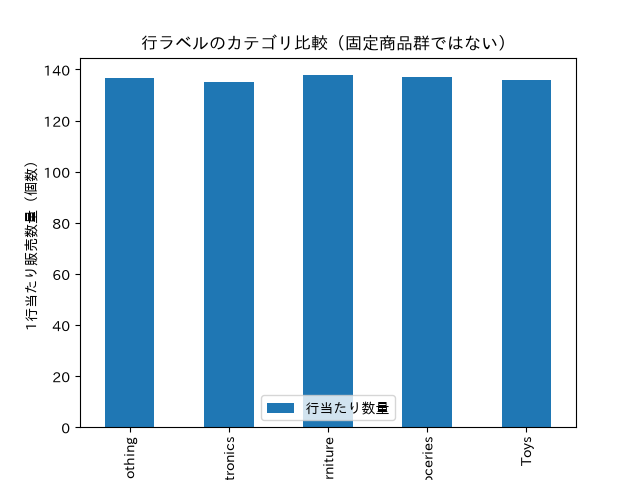

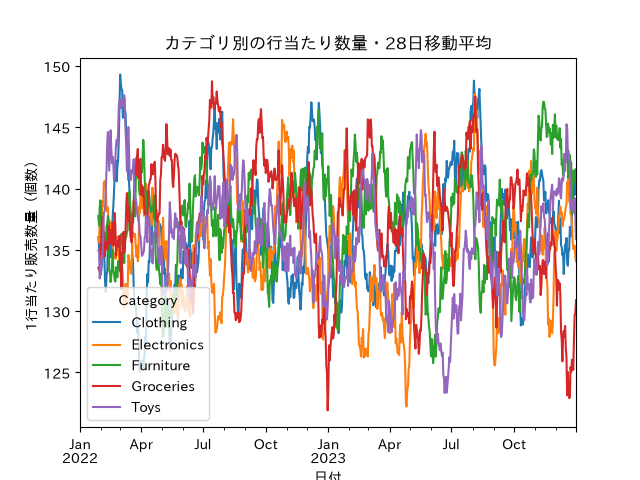

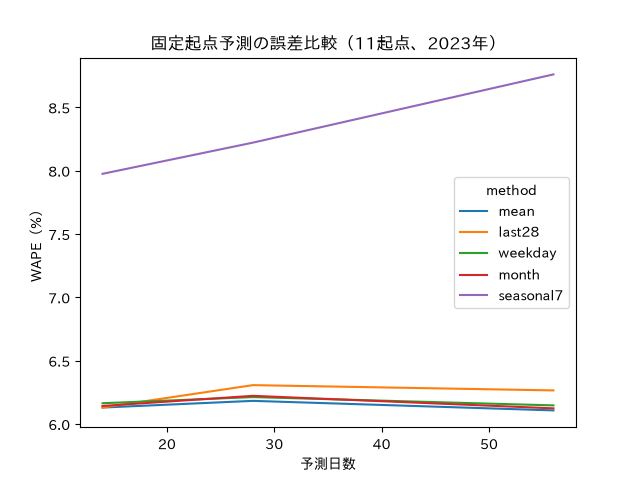

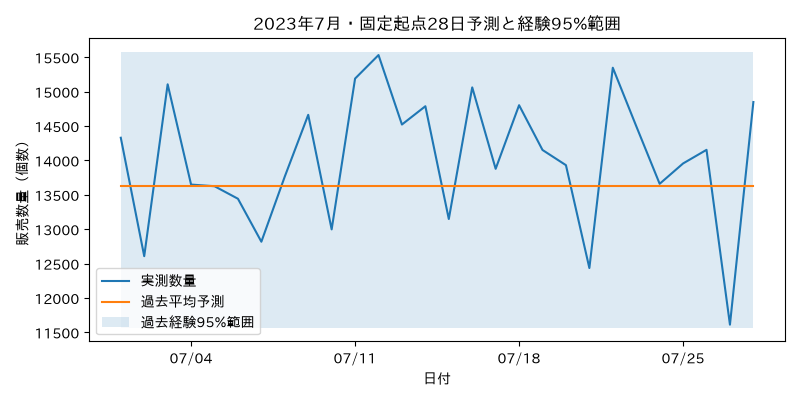

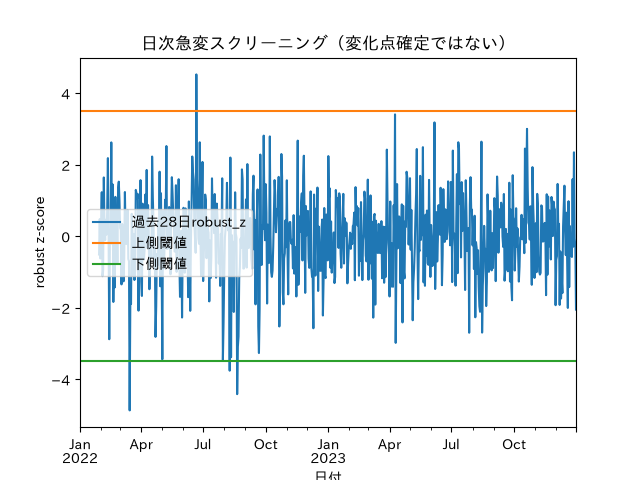

In [10]:
# CHART: comparisons-and-forecast
checked_start()
try:
    cat_bar = category_summary.reset_index().rename(columns={'mean': '行当たり数量'})
    show_chart(cat_bar, 'bar', 'Category', '行当たり数量', '行ラベルのカテゴリ比較（固定商品群ではない）', 'カテゴリラベル', '1行当たり販売数量（個数）', 'category-normalized.png')
    cat_trend = category_means_daily.rolling(28, min_periods=28).mean().rename_axis('Date').reset_index()
    show_chart(cat_trend, 'line', 'Date', list(category_means_daily.columns), 'カテゴリ別の行当たり数量・28日移動平均', '日付', '1行当たり販売数量（個数）', 'category-timeseries.png')
    wape_chart = forecast_metrics['WAPE_pct'].unstack().reset_index().rename(columns={'horizon': '予測日数'})
    show_chart(wape_chart, 'line', '予測日数', methods, '固定起点予測の誤差比較（11起点、2023年）', '予測日数', 'WAPE（%）', 'forecast-wape.png')
    example_origin = pd.Timestamp('2023-07-01')
    example = forecast_cases.loc[forecast_cases.origin.eq(example_origin) & forecast_cases.horizon.eq(28) & forecast_cases.method.eq('mean')].set_index('date')[['actual', 'prediction']].rename(columns={'actual': '実測数量', 'prediction': '過去平均予測'})
    interval_example = interval_table.loc[interval_table.origin.eq(example_origin) & interval_table.level.eq(0.95)].iloc[0]
    example['経験95%下限'] = interval_example.lower
    example['経験95%上限'] = interval_example.upper
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    with warnings.catch_warnings(record=True) as caught_example:
        warnings.simplefilter('always')
        fig, ax = plt.subplots(figsize=(8, 4))
        try:
            ax.plot(example.index, example['実測数量'], label='実測数量')
            ax.plot(example.index, example['過去平均予測'], label='過去平均予測')
            ax.fill_between(example.index, example['経験95%下限'], example['経験95%上限'], alpha=0.15, label='過去経験95%範囲')
            ax.set(title='2023年7月・固定起点28日予測と経験95%範囲', xlabel='日付', ylabel='販売数量（個数）')
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
            ax.legend(loc='lower left')
            fig.tight_layout()
            image_buffer = io.BytesIO()
            fig.savefig(image_buffer, format='png')
            example_png = image_buffer.getvalue()
        finally:
            plt.close(fig)
    assert not [w for w in caught_example if 'Glyph' in str(w.message)]
    chart_registry['forecast-example.png'] = {'title': '2023年7月・固定起点28日予測と経験95%範囲', 'xlabel': '日付', 'ylabel': '販売数量（個数）', 'legend': ['実測数量', '過去平均予測', '過去経験95%範囲'], 'missing_glyphs': [], 'glyph_check': 'matplotlib警告検査', 'sha256': hashlib.sha256(example_png).hexdigest()}
    (data_dir / 'forecast-example.png').write_bytes(example_png)
    display(visualization.build_image_output(example_png)['data'], raw=True)
    z_chart = pd.DataFrame({'日付': complete_daily.index, '過去28日robust_z': robust_z, '上側閾値': 3.5, '下側閾値': -3.5})
    show_chart(z_chart, 'line', '日付', ['過去28日robust_z', '上側閾値', '下側閾値'], '日次急変スクリーニング（変化点確定ではない）', '日付', 'robust z-score', 'change-screening.png')
finally:
    checked_end()

In [11]:
# 監査機能の最小再現と適用できない機能の記録。
from ai_data_scientist import insight_engine
checked_start()
try:
    # 監査メタデータなしの実PNGを含む最小Notebook。
    png_probe = (data_dir / 'daily-trend.png').read_bytes()
    probe_cell = nbformat.v4.new_code_cell('実描画の監査メタデータ欠落を検査')
    probe_cell.execution_count = 1
    probe_cell.outputs = [visualization.build_image_output(png_probe)]
    probe_nb = nbformat.v4.new_notebook(cells=[probe_cell])
    no_metadata_findings = notebook_audit.audit_visual_outputs(probe_nb, (0,))
    print('図メタデータ欠落の再現結果:', [asdict(f) for f in no_metadata_findings])
    current_boot = nbformat.read(handle.notebook_path, as_version=4)
    printed_evidence_cell = next(c for c in current_boot.cells if c.cell_type == 'code' and c.source.startswith('# 初回分析:'))
    printed_output = ''.join(o.get('text', '') for o in printed_evidence_cell.outputs if o.output_type == 'stream')
    print_citation = insight_engine.extract_cited_value({'output': printed_output}, r'"daily_mean": ([0-9.]+)')
    probe_handle = handle
    stream_rejected = False
    try:
        insight_engine.record_insight(probe_handle, '検査用: 実行済みprint出力の引用', printed_evidence_cell.execution_count, print_citation, 'descriptive', language='ja')
    except insight_engine.EvidenceMissingError:
        stream_rejected = True
    print('実際に存在するstreamの引用値:', print_citation, 'EvidenceMissingError:', stream_rejected)
    improvement_candidates = []
    if not no_metadata_findings:
        improvement_candidates.append({'classification': 'Jupytermind監査の検査漏れ', 'module': 'ai_data_scientist.notebook_audit.audit_visual_outputs', 'reproduction': '実PNGを含むcode cellのmetadata.chartを省略しaudit_visual_outputsを呼ぶ', 'expected': 'グリフ検査情報・タイトル・軸・凡例の欠落を報告', 'actual': 'findings=[]。メタデータが空だとmissing_labelもmissing_glyphsも検査されない', 'impact': '未監査図がvisual audit成功と誤認され得る', 'workaround': '各図の実タイトル・軸・凡例・Glyph警告検査情報を明示しPNGを目視確認', 'related_cells': ['監査機能の最小再現', 'CHART: initial-overview', 'CHART: comparisons-and-forecast', '最終監査'], 'log': 'data/improvement_logs.json'})
    if stream_rejected:
        improvement_candidates.append({'classification': 'Jupytermind証拠出力形式の機能不足', 'module': 'ai_data_scientist.insight_engine.record_insight', 'reproduction': '実行済みセルのprintでdaily_meanを出力、extract_cited_value成功後その実行番号と値をrecord_insightに渡す', 'expected': 'stream.textに存在する根拠値を実行証拠として受理', 'actual': 'EvidenceMissingError。data MIMEのみ検索しstream.textは検索しない', 'impact': '通常のprint出力を証拠に使えない', 'workaround': '最終証拠セルをdisplay(text/plain)で出力し実行番号と引用値を検証', 'related_cells': ['初回分析', '監査機能の最小再現', '最終証拠'], 'log': 'data/improvement_logs.json'})
    applicability = {'mcp_gateway.run_and_record': '適用せず。ホストのJupyter MCP execute_cellを直接呼ぶ。カーネル内にMCPClient.executeのホストtransportを提供できないため、偽クライアントやローカルexecで代替しない。Notebook内容の保存はenqueue_write、実行と実出力保存はJupyter MCP。', 'data_quality.validate_anomalies': '独立参照データが与えられておらず、同じ合成データの別コピーで独立検証を装わない。', 'dataset_validation.compare_datasets': '独立した第二データセット未指定・未取得のため適用不可。', 'causal_analysis': 'ランダム割付・自然実験・生成DAG不明。販売促進や天候の因果効果を推定しない。', 'real_revenue': '通貨・Priceの値引含有・税・返品が不明。数量と未確認代理値を分離。', 'formal_change_point': '日次候補は閾値スクリーニングのみ。確定変化点検定・イベント外部検証は行っていない。', 'tables_visual_audit': 'notebook_auditのvisual_auditはPNGのみ。表は明示単位・母数・完全月フラグ・空表の候補数表示とコード検査で補う。', 'fallback': 'Kaggle API取得成功のためwhite-paper CSVへのフォールバックは不要。'}
    environment_notes = [{'classification': 'Kaggle SDK呼出引数', 'actual': 'dataset_listにpage_sizeを渡すとTypeError', 'workaround': '公開docstringのsearch引数だけを使って再取得済み', 'jupytermind_issue': False}, {'classification': '分析セルの列名指定', 'actual': '共有DatetimeIndexの名前が日付となり図でDate参照がKeyError', 'workaround': '図用コピーでrename_axis(Date)、再実行して解消', 'jupytermind_issue': False}, {'classification': 'Kaggle SDK機能照会', 'actual': 'dataset_viewが未実装', 'workaround': '既存dataset_metadataからinfo.descriptionを利用', 'jupytermind_issue': False}, {'classification': 'Copilot CLI / MCP準備', 'actual': '初回use_notebookでは保存先の親ディレクトリがまだ存在せずcreateできなかった', 'workaround': 'bootstrapからproject_manager.ensure_notebookで親を準備', 'jupytermind_issue': False}]
    print('Jupytermind改善候補:', json.dumps(improvement_candidates, ensure_ascii=False))
    print('非適用理由:', json.dumps(applicability, ensure_ascii=False))
    print('環境・呼出側の問題:', json.dumps(environment_notes, ensure_ascii=False))
    (data_dir / 'improvement_logs.json').write_text(json.dumps({'candidates': improvement_candidates, 'probes': {'visual_findings_without_metadata': [asdict(f) for f in no_metadata_findings], 'actual_print_citation': print_citation, 'stream_rejected': stream_rejected}, 'environment_notes': environment_notes}, ensure_ascii=False, indent=2), encoding='utf-8')
finally:
    checked_end()

図メタデータ欠落の再現結果: []
実際に存在するstreamの引用値: 13647.038356164383 EvidenceMissingError: True
Jupytermind改善候補: [{"classification": "Jupytermind監査の検査漏れ", "module": "ai_data_scientist.notebook_audit.audit_visual_outputs", "reproduction": "実PNGを含むcode cellのmetadata.chartを省略しaudit_visual_outputsを呼ぶ", "expected": "グリフ検査情報・タイトル・軸・凡例の欠落を報告", "actual": "findings=[]。メタデータが空だとmissing_labelもmissing_glyphsも検査されない", "impact": "未監査図がvisual audit成功と誤認され得る", "workaround": "各図の実タイトル・軸・凡例・Glyph警告検査情報を明示しPNGを目視確認", "related_cells": ["監査機能の最小再現", "CHART: initial-overview", "CHART: comparisons-and-forecast", "最終監査"], "log": "data/improvement_logs.json"}, {"classification": "Jupytermind証拠出力形式の機能不足", "module": "ai_data_scientist.insight_engine.record_insight", "reproduction": "実行済みセルのprintでdaily_meanを出力、extract_cited_value成功後その実行番号と値をrecord_insightに渡す", "expected": "stream.textに存在する根拠値を実行証拠として受理", "actual": "EvidenceMissingError。data MIMEのみ検索しstream.textは検索しない", "impact": "通常のprint出力を証拠に使えない", "workaround": "最終証拠セルをdis

In [12]:
# 最終証拠: 再計算された根拠値をMIME出力で保存する。
checked_start()
try:
    final_evidence = {
        'source': provenance,
        'synthetic': metadata_info.get('userSpecifiedSources'),
        'coverage': {'rows': len(df), 'days': len(calendar), 'stores': df['Store ID'].nunique(), 'products': df['Product ID'].nunique(), 'missing_keys': len(missing_keys), 'missing_dates': len(missing_dates), 'daily_rows': int(coverage.min()), 'incomplete_month': '2024-01:1/31'},
        'seasonality': {'month_year_r': month_correlation.statistic, 'month_year_p': month_correlation.p_value, 'acf7': float(complete_daily.autocorr(7)), 'acf365': float(complete_daily.autocorr(365)), 'permutation': permutation_records, 'month_spread_pct': month_spread.to_dict()},
        'comparison': {'store_max_min_pct': units_stats['store_mean_max_min_pct'], 'category_total_max_min_pct': units_stats['category_total_max_min_pct'], 'category_per_row_max_min_pct': units_stats['category_per_row_max_min_pct'], 'all_8_simultaneous_CIs_include_zero': bool((comparison_ci.simultaneous95_low.le(0) & comparison_ci.simultaneous95_high.ge(0)).all()), 'category_switch_rate': label_checks['category_switch_rate'], 'region_switch_rate': label_checks['region_switch_rate']},
        'forecast': {'mean_28_WAPE_pct': float(forecast_metrics.loc[(28, 'mean'), 'WAPE_pct']), 'weekday_28_WAPE_pct': float(forecast_metrics.loc[(28, 'weekday'), 'WAPE_pct']), 'month_28_WAPE_pct': float(forecast_metrics.loc[(28, 'month'), 'WAPE_pct']), 'seasonal7_28_WAPE_pct': float(forecast_metrics.loc[(28, 'seasonal7'), 'WAPE_pct']), 'store_mean_WAPE_range_pct': [float(store_forecast.xs('mean', level='method').WAPE_pct.min()), float(store_forecast.xs('mean', level='method').WAPE_pct.max())], 'interval95_width': float(interval_summary.loc[0.95, 'width']), 'interval95_coverage': float(interval_summary.loc[0.95, 'coverage']), 'sensitivity_stable': forecast_sensitivity.stable, 'max_relative_deviation': forecast_sensitivity.max_relative_deviation, 'leakage_warning': leakage_check},
        'changes': {'initial_flags': len(initial_flags), 'min_spec_flags': min(x['n_flags'] for x in sensitivity_counts), 'max_spec_flags': max(x['n_flags'] for x in sensitivity_counts), 'stable': change_sensitivity.stable, 'max_relative_deviation': change_sensitivity.max_relative_deviation, 'persistent_14_day_pct': [float(persistence_table.next14_vs_prev14_pct.min()), float(persistence_table.next14_vs_prev14_pct.max())], 'all9_dates': [str(d.date()) for d in candidate_stability.loc[candidate_stability.n_specs.eq(9), 'date']]},
        'money_sensitivity': {'year_change_pct': year_change, 'stable': money_sensitivity.stable, 'max_relative_deviation': money_sensitivity.max_relative_deviation},
        'iteration_count': len(iteration_history),
        'improvement_candidate_count': len(improvement_candidates)
    }
    assert len(iteration_history) == 3
    assert len(df) == len(expected) and df.duplicated(key).sum() == 0
    assert forecast_cases.groupby(['origin', 'horizon', 'method']).size().eq(forecast_cases.groupby(['origin', 'horizon', 'method']).horizon.first()).all()
    (data_dir / 'final_evidence.json').write_text(json.dumps(final_evidence, ensure_ascii=False, indent=2), encoding='utf-8')
    (data_dir / 'data_definition_manifest.json').write_text(json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str, indent=2), encoding='utf-8')
    (data_dir / 'analysis_assumptions_manifest.json').write_text(json.dumps(asdict(assumptions_manifest), ensure_ascii=False, indent=2), encoding='utf-8')
    (data_dir / 'iteration_history.json').write_text(json.dumps(iteration_history, ensure_ascii=False, indent=2), encoding='utf-8')
    display({'text/plain': json.dumps(final_evidence, ensure_ascii=False, indent=2)}, raw=True)
finally:
    checked_end()

{
  "source": {
    "slug": "anirudhchauhan/retail-store-inventory-forecasting-dataset",
    "filename": "retail_store_inventory.csv",
    "retrieved_at_utc": "2026-10-01T21:48:03.215973+00:00",
    "sha256": "c7b6019887d85e6bb311a76da72560463e6bf269bfadbe4b326fbff3b1000468",
    "method": "Kaggle Python SDK dataset_download_file",
    "url": "https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset"
  },
  "synthetic": "Synthetic Dataset created in own workspace",
  "coverage": {
    "rows": 73100,
    "days": 731,
    "stores": 5,
    "products": 20,
    "missing_keys": 0,
    "missing_dates": 0,
    "daily_rows": 100,
    "incomplete_month": "2024-01:1/31"
  },
  "seasonality": {
    "month_year_r": 0.395367853021756,
    "month_year_p": 0.20334286825784387,
    "acf7": -0.010411405121010773,
    "acf365": 0.07006897799596258,
    "permutation": [
      {
        "year": 2022,
        "observed_max_min_units": 665.4654377880179,
        "permutation_

## 取得情報・再現方法

{
  "slug": "anirudhchauhan/retail-store-inventory-forecasting-dataset",
  "filename": "retail_store_inventory.csv",
  "retrieved_at_utc": "2026-10-01T21:48:03.215973+00:00",
  "sha256": "c7b6019887d85e6bb311a76da72560463e6bf269bfadbe4b326fbff3b1000468",
  "method": "Kaggle Python SDK dataset_download_file",
  "url": "https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset"
}

取得日時は初回取得を保持し、再実行では原本SHA-256を照合する。検索・ファイル一覧・必要時のダウンロードはKaggle Python SDKをJupyter MCPセル内で実行。選定理由は日付、店舗ID、商品ID、カテゴリがある検索結果の公開CSVであること。実売上ではなく合成データなので現実の店舗の経営判断には外挿しない。原本・出典説明・集計CSV・図・manifestは隣接data/に保存。認証はSDKの設定を使い、トークン値を記録しない。

**再現実行:** カーネルを再起動し、全コードセルを上から順に実行する。乱数seedは35・3502。実行番号に紐付く証拠のため、途中セルだけの再実行ではなくRestart Kernel and Run Allを使用する。制作補助の文書生成は完了済みで、最終監査セルはNotebookを再構成しない。

## 集計粒度と欠損期間

日付×店舗ID×商品IDの1行。2022-01-01〜2024-01-01、731日×5店舗×20商品=73,100行で全組合せが揃い、欠損日・複合キー欠損・重複は0。販売ゼロは欠損と区別する。2024年1月は1/31日なので完全月・年比較から除外。日計と7日移動平均、月の日平均、完全な月曜〜日曜週を使用。月合計の大小は月日数に影響されるため、季節性は日平均で比較する。カテゴリの日々の母数は変動するので合計と行当たり平均を分ける。

## データ定義manifest・分析前提manifest

実行セルに全文を表示しdata/data_definition_manifest.jsonとdata/analysis_assumptions_manifest.jsonに保存。Units Soldは当日の販売個数、金銭売上でも潜在需要でもない。異なる商品の個数の合計は販売活動規模の指標であり経済価値の加重合計ではない。Priceの通貨・値引含有、税・返品、Seasonalityの暦定義、Demand Forecastの起点可用性は未解決。

check_manifestの警告は全件報告済み: fixed-categoryはrejected（固定商品群の比較を棄却）、revenue-definitionとfuture-stabilityはassumed。説明上の但し書きを検証済みと扱わない。カテゴリ差は行ラベルの記述、金額は未確認代理値、予測は過去の合成データ内に限定する。

## 反復依頼履歴

### 反復1

追加依頼文（原文）:

カテゴリ総売上の差が販売行数の差によるものか、1行当たり販売数量の差によるものかを分解してください。同一商品のカテゴリ変更と同一店舗の地域変更を定量化し、Seasonalityラベルが暦の季節を意味するか確認してください。月別の形状が翌年にも再現するかと、店舗・カテゴリ差の不確実性を日単位のブロック再標本化で調べてください。

選定理由: ラベル固定性とカテゴリ構成・月形状の再現性

結果: {"labels": {"category_switch_rate": 0.7996712328767124, "region_switch_rate": 0.7493561643835617, "all_product_ids_multicategory": 20, "all_store_ids_multiregion": 5, "days_with_all_four_seasonality_labels": 731, "days_observed": 731}, "decomposition": {"comparison": "Furniture/Electronics", "total_ratio": 1.0329442694263304, "row_count_ratio": 1.0122581089456648, "per_row_units_ratio": 1.0204356579590275}, "month_correlation": {"statistic": 0.395367853021756, "p_value": 0.20334286825784387, "interpretation": "相関係数は 0.3954 (p=0.2033) で、中程度の正の相関が見られます。"}}

証拠: このセルのラベル検査、乗法分解、同時95%区間、暦月シャッフル表

残る限界: 合成データ、カテゴリ不安定、月12組、2年、探索的検定

### 反復2

追加依頼文（原文）:

月や曜日のパターンが実際に予測へ役立つか、2023年の複数起点から14・28・56日先を時間順に検証してください。過去平均、直近平均、曜日平均、月平均、7日季節ナイーブを同じ期間で比較し、全店合計と店舗別の誤差、予測区間の幅と被覆率を示してください。Demand Forecast列に目的変数リークを疑う根拠があるかも確認し、使用可否を説明してください。

選定理由: 時系列外部評価と既存予測列の可用性

結果: {"mean_28_WAPE_pct": 6.181782065966815, "sensitivity_stable": false, "max_relative_deviation": 0.4169196921119975, "leakage_check": {"same_row_correlation": 0.9968530435356839, "residual_min": -10.0, "residual_max": 20.0, "residual_mean": 5.029850068399453, "negative_forecast_rows": 673, "same_row_MAE": 8.338075512995896}}

証拠: このセルの起点別・店舗別予測表と区間、感度report、既存予測残差

残る限界: 合成過程、2年、11起点の重複、経験区間は分布安定性仮定、リークは未確証

### 反復3

追加依頼文（原文）:

初回の急変候補について、過去14・28・56日の窓と閾値3・3.5・4を変えて再検出し、店舗ごとの寄与とその後14日間の持続性を比較してください。日次・完全週で候補がどう変わるか、販売数量とPrice×Units Soldの未確認金額代理値、割引を反映した代理値で年比較が変わるかも調べ、頑健でない結論を明示してください。

選定理由: 急変の閾値・窓・集計粒度依存と金額定義

結果: {"change_stable": false, "change_max_relative_deviation": 4.5, "weekly_flags": 6, "year_change_pct": {"units": -0.41890174420188275, "gross_proxy": -0.9179457835689853, "discount_proxy": -1.0329910096456785}, "money_stable": false, "money_max_relative_deviation": 1.4659506052279543}

証拠: このセルの9仕様候補数・日付一致・持続性・店舗寄与・週次・数量/金額代理感度

残る限界: 候補は確定変化点でない、金額意味不明、独立参照なし、現実市場への外挿不可

3回で終了。残る未解決点は出典の生成方法、独立参照、実売上定義などであり、追加探索で有意な差を探すことはしない。

## 使用したJupytermindモジュール

直接import・呼び出したもののみ。間接利用は含めない。

| モジュール | 直接使用した関数・型・メソッド | 使用目的 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先の検証・安定パス・単一ライターによるNotebook保存 |
| ai_data_scientist.language_router | detect_language | 日本語指示の検出 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行・書込み・終了状態の追跡 |
| ai_data_scientist.ingestion | SourceSpec, ingest | 取得CSVの読込と行数上限 |
| ai_data_scientist.cleaning | clean_dataset | 重複除去の影響（削除0件）確認 |
| ai_data_scientist.eda | explore | 型・欠損・カテゴリ・要約統計の基礎探索 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 出典・単位・定義の検証状態と未解決定義 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 集計・因果範囲・適用前提の監査 |
| ai_data_scientist.data_quality | detect_anomalies | 負の予測・非欠損・値域・二値制約 |
| ai_data_scientist.stats_analysis | correlation | 2年の月別形状を日本語解釈付きで比較 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 予測15仕様・急変9仕様・指標3仕様の感度 |
| ai_data_scientist.visualization | render_chart, build_image_output | 日本語図の描画・Notebookへの実PNG出力 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 実出力から引用値を抽出して結論の証拠を照合 |
| ai_data_scientist.notebook_audit | audit_visual_outputs, audit_notebook | 監査の最小再現と最終visual_audit=True監査 |

matplotlibは予測例の日付目盛を週単位に整えるため直接利用した（render_chartには目盛指定の引数がない）。その図もbuild_image_output、Glyph警告検査、PNG監査の対象とした。

## 適用できない機能・適用範囲

**mcp_gateway.run_and_record**: 適用せず。ホストのJupyter MCP execute_cellを直接呼ぶ。カーネル内にMCPClient.executeのホストtransportを提供できないため、偽クライアントやローカルexecで代替しない。Notebook内容の保存はenqueue_write、実行と実出力保存はJupyter MCP。

**data_quality.validate_anomalies**: 独立参照データが与えられておらず、同じ合成データの別コピーで独立検証を装わない。

**dataset_validation.compare_datasets**: 独立した第二データセット未指定・未取得のため適用不可。

**causal_analysis**: ランダム割付・自然実験・生成DAG不明。販売促進や天候の因果効果を推定しない。

**real_revenue**: 通貨・Priceの値引含有・税・返品が不明。数量と未確認代理値を分離。

**formal_change_point**: 日次候補は閾値スクリーニングのみ。確定変化点検定・イベント外部検証は行っていない。

**tables_visual_audit**: notebook_auditのvisual_auditはPNGのみ。表は明示単位・母数・完全月フラグ・空表の候補数表示とコード検査で補う。

**fallback**: Kaggle API取得成功のためwhite-paper CSVへのフォールバックは不要。

## Jupytermind改善候補

### 候補1

**classification**: Jupytermind監査の検査漏れ

**module**: ai_data_scientist.notebook_audit.audit_visual_outputs

**reproduction**: 実PNGを含むcode cellのmetadata.chartを省略しaudit_visual_outputsを呼ぶ

**expected**: グリフ検査情報・タイトル・軸・凡例の欠落を報告

**actual**: findings=[]。メタデータが空だとmissing_labelもmissing_glyphsも検査されない

**impact**: 未監査図がvisual audit成功と誤認され得る

**workaround**: 各図の実タイトル・軸・凡例・Glyph警告検査情報を明示しPNGを目視確認

**related_cells**: ["監査機能の最小再現", "CHART: initial-overview", "CHART: comparisons-and-forecast", "最終監査"]

**log**: data/improvement_logs.json

### 候補2

**classification**: Jupytermind証拠出力形式の機能不足

**module**: ai_data_scientist.insight_engine.record_insight

**reproduction**: 実行済みセルのprintでdaily_meanを出力、extract_cited_value成功後その実行番号と値をrecord_insightに渡す

**expected**: stream.textに存在する根拠値を実行証拠として受理

**actual**: EvidenceMissingError。data MIMEのみ検索しstream.textは検索しない

**impact**: 通常のprint出力を証拠に使えない

**workaround**: 最終証拠セルをdisplay(text/plain)で出力し実行番号と引用値を検証

**related_cells**: ["初回分析", "監査機能の最小再現", "最終証拠"]

**log**: data/improvement_logs.json

### 切り分け

[
  {
    "classification": "Kaggle SDK呼出引数",
    "actual": "dataset_listにpage_sizeを渡すとTypeError",
    "workaround": "公開docstringのsearch引数だけを使って再取得済み",
    "jupytermind_issue": false
  },
  {
    "classification": "分析セルの列名指定",
    "actual": "共有DatetimeIndexの名前が日付となり図でDate参照がKeyError",
    "workaround": "図用コピーでrename_axis(Date)、再実行して解消",
    "jupytermind_issue": false
  },
  {
    "classification": "Kaggle SDK機能照会",
    "actual": "dataset_viewが未実装",
    "workaround": "既存dataset_metadataからinfo.descriptionを利用",
    "jupytermind_issue": false
  },
  {
    "classification": "Copilot CLI / MCP準備",
    "actual": "初回use_notebookでは保存先の親ディレクトリがまだ存在せずcreateできなかった",
    "workaround": "bootstrapからproject_manager.ensure_notebookで親を準備",
    "jupytermind_issue": false
  }
]

SDKの引数・機能差、呼出側の列名、MCPの親ディレクトリ準備はJupytermind候補とは別。ベンチマークランナー固有の不具合は観測していない。

### 制作補助・再実行時の問題

{
  "json_comparison": {
    "classification": "分析側のJSON比較",
    "cause": "月別表の整数年キーがJSONでは文字列になりPython辞書と直接比較すると不一致",
    "evidence": true,
    "observed_failed_status": {
      "run_id": "v020-exp-35",
      "state": "failed",
      "active_cell_executions": 0,
      "pending_notebook_writes": 0,
      "locks_held": 0,
      "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-35-retail-sales/notebooks/kaggle-v020-kaggle-exp-35-retail-sales.ipynb",
      "reason": null
    },
    "workaround": "同じJSON表現に正規化して比較。分析結果は変更しない。",
    "jupytermind_issue": false
  },
  "mcp_boundary": {
    "classification": "Jupyter MCPと実行中Notebookの外部更新連携",
    "actual": "実行セル自身をenqueue_writeで移動・再構成すると、実行は完了してもMCPが結果を元の位置へ保存できず、末尾コードセルの実行番号と出力が未保存となった。cell_id指定でも接続キャッシュの再読込が必要だった。",
    "workaround": "文書生成を非アクティブNotebookへの制作補助書込みで完了し、最終セルは読取専用監査とする。最後にカーネルを再起動して全13セルを再実行。",
    "jupytermind_issue": false,
    "classification_reason": "モジュール単独の再現ではなく、Jupyter MCPが管理する実行セルの位置と外部Notebook再構成の連携問題。候補2件とは切り分け。"
  }
}

関係ログ: data/repair_log.json、data/execution_integration_log.json。いずれも分析・MCP連携側の問題として候補2件と区別した。

## 結果・予測可能性の限界

以下の段落は最終証拠セルの実出力から引用値を抽出し、insight_engineで照合して保存する。CI・p値は合成データの探索的評価であり、季節性の不存在や店舗差の完全な同一性を証明しない。

季節性: 月別日平均の最大最小差は約4.86〜5.56%だが、2年の月形状相関はr=0.395、p=0.203。7日・365日ACFも小さく、翌年に再現する強い季節性の証拠は弱い。月最大最小の探索的シャッフルp値は2022年約0.298、2023年約0.192。2年しかなく弱い周期を否定できない。Seasonalityは全731日に全4ラベルがあり暦の代理として使えない。

```evidence
{"execution_count":12,"cited_value":"0.395367853021756","claim_type":"descriptive"}
```

店舗・カテゴリ差: 店舗の日平均の最大最小差は約2.34%。カテゴリ合計差約3.29%は行数比約1.0123×行当たり数量比約1.0204で、母数補正後は約2.04%。固定基準との8比較のブロックbootstrap同時95%区間はすべて0を含む。ただし差が存在しないことの証明ではない。同一店舗商品のカテゴリは日次で約79.97%が変更され、固定商品群の需要差には解釈できない。

```evidence
{"execution_count":12,"cited_value":"2.338872808937764","claim_type":"descriptive"}
```

急な変化: 初回過去28日・閾値3.5では4候補。全仕様を同じ674日で比較すると2〜22候補で、SensitivityReport.stable=False、max_relative_deviation=4.5。9仕様すべてで2022-03-15と2022-06-21を検出。候補の後14日平均と前14日平均の差は約-2.69〜+2.71%で、当日の大変動が同程度の恒久的水準変化として持続したとは言えない。外部イベントとの因果対応・正式な変化点確定はしていない。

```evidence
{"execution_count":12,"cited_value":"4","claim_type":"descriptive"}
```

予測可能性: 2023年の11固定起点・28日予測のWAPEは過去平均6.18%、曜日平均6.21%、月平均6.22%、7日季節ナイーブ8.22%。暦情報による改善は確認できず、起点対応差の参考CIも月・曜日では0を跨ぐ。個店の過去平均WAPEは約13.77〜14.52%。合計の低誤差は100商品店舗行の平均化を含み、個別需要が予測しやすいとは意味しない。経験95%区間の平均幅は約4,001個、被覆率95.78%で、安定分布を仮定しても日次の不確実性は広い。14・28・56日と5法の感度はstable=False、最大相対差約41.69%。すべてのモデルが同程度とは主張しない。

```evidence
{"execution_count":12,"cited_value":"6.181782065966815","claim_type":"descriptive"}
```

予測列・定義の限界: Demand Forecastと当日Units Soldの相関は約0.99685、残差は-10〜20個、負の予測673行。目的値から作成された疑いがあるがリークは未確証。起点での利用可否が不明なのでモデル入力にも有効な既存モデル比較にも使わない。販売数量は在庫制約を受ける観測値で潜在需要ではなく、促進・天候の因果効果も未識別。独立参照・生成方法・現実の母集団への対応がないので実市場へ予測精度を外挿できない。

```evidence
{"execution_count":12,"cited_value":"0.9968530435356839","claim_type":"descriptive"}
```

数量と金額代理の感度: 2023/2022の日平均は数量約-0.419%、Price×Units Sold約-0.918%、割引率を百分率と仮定した代理値約-1.033%。方向は同じだが大きさは不安定（stable=False、最大相対差約146.60%）。通貨・Priceの値引含有・税・返品が不明なため代理値を実売上として扱わず、主結論は販売数量について述べる。

```evidence
{"execution_count":12,"cited_value":"-0.41890174420188275","claim_type":"descriptive"}
```

## 最終監査・ライフサイクル記録

カーネル再起動後、全13コードセルを上から再実行。実行番号は1〜13、コードエラー0、未実行0、PNG図8枚。完了後のnotebook_audit(visual_audit=True)はok=True、findings=[]、visual_findings=[]、根拠付き結論6段落。実行中の自己監査では最後のセルが除外されるが、完了後の外側監査では13/13実行済みを確認した。

run_id=`v020-exp-35`、lifecycle=`completed`、active_cell_executions=0、pending_notebook_writes=0、locks_held=0。Notebook metadata.terminal_auditとmetadata.lifecycle、data/notebook_audit_postexecution.json、data/lifecycle.jsonに記録。3回の反復と、適用不可理由、未解決定義・前提、改善候補2件と回避策を記録済み。

In [13]:
# 最終監査: 実行中のNotebookを再構成せず、実出力を読み取り監査する。
import base64
if lifecycle.get_run_status(RUN_ID).state != 'running':
    lifecycle.register_run(RUN_ID, handle.notebook_path)
checked_start()
try:
    audit_input = nbformat.read(handle.notebook_path, as_version=4)
    summary_cell = next(c for c in audit_input.cells if c.cell_type == 'code' and c.source.startswith('# 最終証拠:'))
    summary_text = '\n'.join(str(o.get('data', {}).get('text/plain', '')) for o in summary_cell.outputs)
    assert json.loads(summary_text) == json.loads(json.dumps(final_evidence, ensure_ascii=False))
    if summary_cell.execution_count != 12:
        raise RuntimeError('根拠の実行番号を揃えるためカーネルを再起動して全セルを上から実行してください')
    for cell in audit_input.cells:
        if cell.cell_type == 'code' and any('image/png' in o.get('data', {}) for o in cell.outputs):
            assert cell.metadata.get('chart', {}).get('glyph_check')
            assert cell.metadata['chart']['missing_glyphs'] == []
            images = [o['data']['image/png'] for o in cell.outputs if 'image/png' in o.get('data', {})]
            assert len(cell.metadata['chart_outputs']) == len(images)
            for image, specification in zip(images, cell.metadata['chart_outputs'], strict=True):
                assert hashlib.sha256(base64.b64decode(image)).hexdigest() == specification['sha256']
    audit_report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    display({'text/plain': json.dumps({'notebook_audit': asdict(audit_report), 'ok': audit_report.ok, 'visual_audit': True, 'glyph_warning_count': sum('Glyph' in warning for warning in chart_warning_log)}, ensure_ascii=False, indent=2)}, raw=True)
    if not audit_report.ok:
        raise RuntimeError('Notebook監査に未解決のエラーがあります')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    checked_end()
lifecycle.mark_completed(RUN_ID)
terminal_status = lifecycle.wait_for_quiescence(RUN_ID, timeout_s=5)
assert terminal_status.state == 'completed' and terminal_status.active_cell_executions == terminal_status.pending_notebook_writes == terminal_status.locks_held == 0
print('lifecycle:', json.dumps(asdict(terminal_status), ensure_ascii=False))
(data_dir / 'lifecycle.json').write_text(json.dumps({'status': asdict(terminal_status), 'events': phase_log}, ensure_ascii=False, indent=2), encoding='utf-8')
(data_dir / 'notebook_audit.json').write_text(json.dumps({'report': asdict(audit_report), 'ok': audit_report.ok, 'note': '監査実行中の最後のセルは完了前なので除外。完了後に全13コードセルの監査を別途記録。'}, ensure_ascii=False, indent=2), encoding='utf-8')


lifecycle: {"run_id": "v020-exp-35", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-35-retail-sales/notebooks/kaggle-v020-kaggle-exp-35-retail-sales.ipynb", "reason": null}


{
  "notebook_audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-35-retail-sales/notebooks/kaggle-v020-kaggle-exp-35-retail-sales.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 13,
    "executed_code_cell_count": 12,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      6,
      10
    ],
    "insight_cell_count": 6,
    "findings": [
      {
        "severity": "warning",
        "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
        "cell_index": 27
      }
    ],
    "visual_findings": []
  },
  "ok": true,
  "visual_audit": true,
  "glyph_warning_count": 0
}

749